In [18]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pykalman import KalmanFilter
import yfinance as yf

In [2]:
t1, t2 = 'MA', 'V'

df_train = yf.download(
    [t1, t2],
    start='2018-01-01',
    end='2025-01-01',
    auto_adjust=False
)

df_test = yf.download(
    [t1, t2],
    start='2025-01-01',
    end='2026-01-01',
    auto_adjust=False
)

train_close = df_train['Adj Close'][[t1, t2]].dropna().copy()
test_close  = df_test['Adj Close'][[t1, t2]].dropna().copy()

x_train = train_close[t1]   # MA
y_train = train_close[t2]   # V

x_test = test_close[t1]
y_test = test_close[t2]

[*********************100%***********************]  2 of 2 completed
[*********************100%***********************]  2 of 2 completed


In [3]:
def calc_kalman_slope_intercept(x, y, delta=1e-5, obs_noise=1.0):
    """
    Online linear regression:
        y_t = beta_t * x_t + intercept_t + noise

    Hidden state = [beta_t, intercept_t]
    """
    x = pd.Series(x).dropna()
    y = pd.Series(y).dropna()
    idx = x.index.intersection(y.index)

    x = x.loc[idx]
    y = y.loc[idx]

    # Source-style transition covariance
    trans_cov = delta / (1.0 - delta) * np.eye(2)

    # observation matrix F_t = [x_t, 1]
    obs_mat = np.vstack([x.values, np.ones(len(x))]).T[:, np.newaxis]

    kf = KalmanFilter(
        n_dim_obs=1,
        n_dim_state=2,
        initial_state_mean=np.zeros(2),
        initial_state_covariance=np.ones((2, 2)),
        transition_matrices=np.eye(2),
        observation_matrices=obs_mat,
        observation_covariance=obs_noise,
        transition_covariance=trans_cov
    )

    state_means, state_covs = kf.filter(y.values)

    out = pd.DataFrame(
        {
            'beta': state_means[:, 0],
            'intercept': state_means[:, 1],
        },
        index=idx
    )

    return out, state_covs, kf

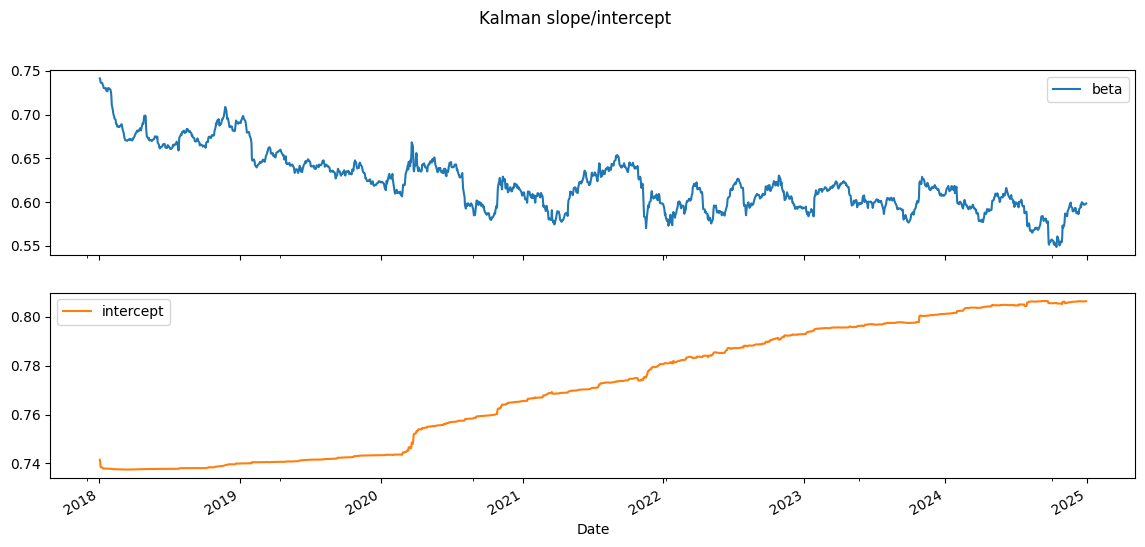

In [4]:
state_train, state_covs_train, kf = calc_kalman_slope_intercept(
    x_train, y_train, delta=1e-5, obs_noise=1.0
)

state_train[['beta', 'intercept']].plot(subplots=True, figsize=(14, 6), title='Kalman slope/intercept')
plt.show()

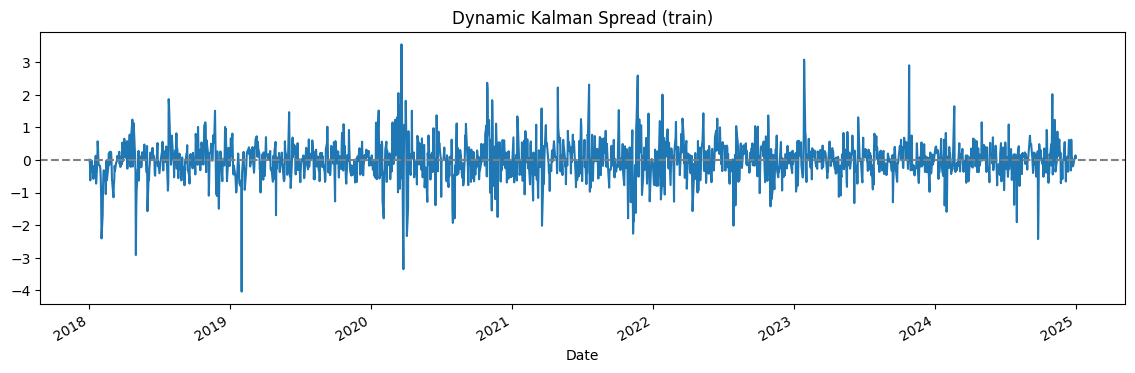

In [5]:
spread_train = y_train.loc[state_train.index] - (
    state_train['beta'] * x_train.loc[state_train.index] + state_train['intercept']
)

spread_train.plot(figsize=(14, 4), title='Dynamic Kalman Spread (train)')
plt.axhline(spread_train.mean(), color='gray', linestyle='--')
plt.show()

In [8]:
def kalman_filter_holdout_online(x_test, y_test, last_state_mean, last_state_cov,
                                 delta=1e-5, obs_noise=1.0):
    """
    Continue the Kalman recursion through holdout data without refitting on future points.
    """
    x_test = pd.Series(x_test).dropna()
    y_test = pd.Series(y_test).dropna()
    idx = x_test.index.intersection(y_test.index)

    x_test = x_test.loc[idx]
    y_test = y_test.loc[idx]

    G = np.eye(2)
    Q = delta / (1.0 - delta) * np.eye(2)
    R = obs_noise

    state_mean = np.asarray(last_state_mean, dtype=float).reshape(2,)
    state_cov = np.asarray(last_state_cov, dtype=float).reshape(2, 2)

    rows = []

    for dt in idx:
        x_t = float(x_test.loc[dt])
        y_t = float(y_test.loc[dt])

        # Predict
        a_t = G @ state_mean                  # shape (2,)
        R_t = G @ state_cov @ G.T + Q        # shape (2,2)

        # Observation matrix F_t = [x_t, 1]
        F_t = np.array([[x_t, 1.0]])         # shape (1,2)

        # Forecast
        yhat_t = (F_t @ a_t).item()
        Q_t = (F_t @ R_t @ F_t.T).item() + R

        # Kalman gain
        K_t = (R_t @ F_t.T) / Q_t            # shape (2,1)

        # Update
        e_t = y_t - yhat_t
        state_mean = a_t + (K_t.flatten() * e_t)
        state_cov = R_t - K_t @ F_t @ R_t

        rows.append({
            'Date': dt,
            'beta': state_mean[0],
            'intercept': state_mean[1],
            'yhat': yhat_t,
            'forecast_error': e_t,
            'forecast_var': Q_t,
        })

    out = pd.DataFrame(rows).set_index('Date')
    return out

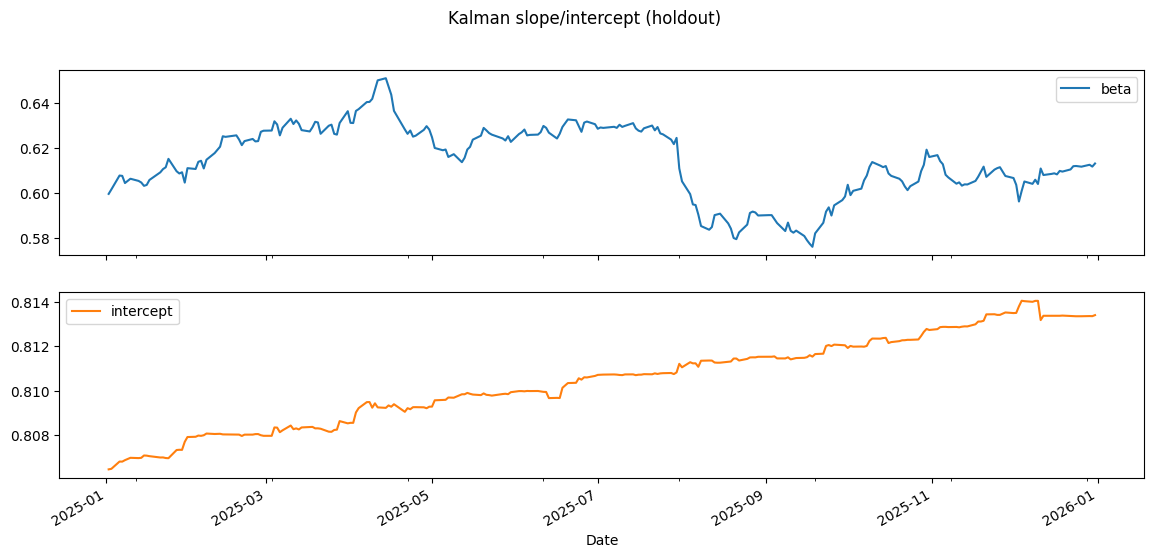

In [9]:
last_state_mean = state_train[['beta', 'intercept']].iloc[-1].values
last_state_cov = state_covs_train[-1]

state_test = kalman_filter_holdout_online(
    x_test, y_test,
    last_state_mean=last_state_mean,
    last_state_cov=last_state_cov,
    delta=1e-5,
    obs_noise=1.0
)

state_test[['beta', 'intercept']].plot(subplots=True, figsize=(14, 6), title='Kalman slope/intercept (holdout)')
plt.show()

In [16]:
def kalman_bollinger_signals(x_prices, y_prices, state_df, window=30, entry=2.0, exit=0.5):
    """
    Dynamic-hedge pairs signal:
    - beta_t and intercept_t come from Kalman filter
    - entry/exit comes from rolling Bollinger bands on the dynamic spread
    """
    idx = state_df.index.intersection(x_prices.index).intersection(y_prices.index)

    x = x_prices.loc[idx]
    y = y_prices.loc[idx]
    s = state_df.loc[idx].copy()

    # Dynamic spread using time-varying beta/intercept
    s['spread'] = y - (s['beta'] * x + s['intercept'])

    # Rolling Bollinger stats on spread
    s['roll_mean'] = s['spread'].rolling(window).mean()
    s['roll_std'] = s['spread'].rolling(window).std()
    s['upper'] = s['roll_mean'] + entry * s['roll_std']
    s['lower'] = s['roll_mean'] - entry * s['roll_std']
    s['zscore'] = (s['spread'] - s['roll_mean']) / s['roll_std']

    # Positions
    s['position'] = np.nan
    s.loc[s['zscore'] > entry, 'position'] = -1   # short spread
    s.loc[s['zscore'] < -entry, 'position'] = 1   # long spread
    s.loc[s['zscore'].abs() < exit, 'position'] = 0
    s['position'] = s['position'].ffill().fillna(0)

    return s

def kalman_bollinger_returns(x_prices, y_prices, signals_df):
    idx = signals_df.index.intersection(x_prices.index).intersection(y_prices.index)

    x = x_prices.loc[idx]
    y = y_prices.loc[idx]
    s = signals_df.loc[idx].copy()

    ret_x = np.log(x / x.shift(1))
    ret_y = np.log(y / y.shift(1))

    # Time-varying hedge ratio
    s['strategy'] = s['position'].shift(1) * (ret_y - s['beta'] * ret_x)

    s['log_cumret'] = s['strategy'].cumsum()
    s['cumret_scaled'] = np.exp(s['log_cumret'])

    total_return = s['cumret_scaled'].iloc[-1] - 1
    annual_ret = np.exp(s['strategy'].mean() * 252) - 1
    sharpe = (s['strategy'].mean() / s['strategy'].std()) * np.sqrt(252)
    max_dd = (s['cumret_scaled'] / s['cumret_scaled'].cummax() - 1).min()

    return s, total_return, annual_ret, sharpe, max_dd

In [32]:
def make_train_walkforward_splits(index, initial_train_years=3, val_months=6, step_months=6):
    index = pd.DatetimeIndex(index).sort_values()
    start = index.min()
    end = index.max()

    splits = []
    train_end = start + pd.DateOffset(years=initial_train_years)

    while True:
        val_end = train_end + pd.DateOffset(months=val_months)
        if val_end > end:
            break

        train_idx = index[index < train_end]
        val_idx = index[(index >= train_end) & (index < val_end)]

        if len(train_idx) > 0 and len(val_idx) > 0:
            splits.append((train_idx, val_idx))

        train_end = train_end + pd.DateOffset(months=step_months)

    return splits

def fit_kalman_train_and_apply_val(x_train, y_train, x_val, y_val, delta=1e-5, obs_noise=1.0):
    state_train, state_covs_train, _ = calc_kalman_slope_intercept(
        x_train, y_train, delta=delta, obs_noise=obs_noise
    )

    last_state_mean = state_train[['beta', 'intercept']].iloc[-1].values
    last_state_cov = state_covs_train[-1]

    state_val = kalman_filter_holdout_online(
        x_val, y_val,
        last_state_mean=last_state_mean,
        last_state_cov=last_state_cov,
        delta=delta,
        obs_noise=obs_noise
    )
    return state_train, state_val


def evaluate_kalman_bollinger_fold(
    x_train, y_train, x_val, y_val,
    window, entry, exit_, delta=1e-5, obs_noise=1.0
):
    if exit_ >= entry:
        return None

    if len(x_train) < max(window + 20, 60) or len(x_val) < max(window + 10, 30):
        return None

    state_train, state_val = fit_kalman_train_and_apply_val(
        x_train, y_train, x_val, y_val, delta=delta, obs_noise=obs_noise
    )

    # seed rolling stats with tail of training dynamic spread
    idx_train = state_train.index.intersection(x_train.index).intersection(y_train.index)
    spread_train = y_train.loc[idx_train] - (
        state_train.loc[idx_train, 'beta'] * x_train.loc[idx_train]
        + state_train.loc[idx_train, 'intercept']
    )

    idx_val = state_val.index.intersection(x_val.index).intersection(y_val.index)
    spread_val = y_val.loc[idx_val] - (
        state_val.loc[idx_val, 'beta'] * x_val.loc[idx_val]
        + state_val.loc[idx_val, 'intercept']
    )

    seeded = pd.concat([spread_train.iloc[-window:], spread_val])

    signals = state_val.loc[idx_val].copy()
    signals['spread'] = spread_val
    signals['roll_mean'] = seeded.rolling(window).mean().loc[idx_val]
    signals['roll_std'] = seeded.rolling(window).std().loc[idx_val]
    signals['zscore'] = (signals['spread'] - signals['roll_mean']) / signals['roll_std']

    signals['position'] = np.nan
    signals.loc[signals['zscore'] > entry, 'position'] = -1
    signals.loc[signals['zscore'] < -entry, 'position'] = 1
    signals.loc[signals['zscore'].abs() < exit_, 'position'] = 0
    signals['position'] = signals['position'].ffill().fillna(0)

    ret_x = np.log(x_val.loc[idx_val] / x_val.loc[idx_val].shift(1))
    ret_y = np.log(y_val.loc[idx_val] / y_val.loc[idx_val].shift(1))

    signals['strategy'] = signals['position'].shift(1) * (ret_y - signals['beta'] * ret_x)
    signals = signals.replace([np.inf, -np.inf], np.nan).dropna(subset=['strategy'])

    if len(signals) < 10 or signals['strategy'].std() == 0:
        return None

    signals['log_cumret'] = signals['strategy'].cumsum()
    signals['cumret_scaled'] = np.exp(signals['log_cumret'])

    total_return = signals['cumret_scaled'].iloc[-1] - 1
    annual_ret = np.exp(signals['strategy'].mean() * 252) - 1
    sharpe = (signals['strategy'].mean() / signals['strategy'].std()) * np.sqrt(252)
    max_dd = (signals['cumret_scaled'] / signals['cumret_scaled'].cummax() - 1).min()
    n_trades = int((signals['position'].diff().abs() > 0).sum())

    return {
        'total_return': total_return,
        'annual_ret': annual_ret,
        'sharpe': sharpe,
        'max_dd': max_dd,
        'n_obs': len(signals),
        'n_trades': n_trades,
    }

def grid_search_kalman_bollinger_cv(
    x_train, y_train,
    windows=(20, 30, 50, 75, 100),
    entries=(1.5, 2.0, 2.5, 3.0),
    exits=(0.25, 0.5, 0.75, 1.0),
    delta=1e-5,
    obs_noise=1.0,
    initial_train_years=3,
    val_months=6,
    step_months=6,
    min_avg_trades=3
):
    splits = make_train_walkforward_splits(
        x_train.index,
        initial_train_years=initial_train_years,
        val_months=val_months,
        step_months=step_months
    )

    results = []
    fold_results = []

    for window, entry, exit_ in product(windows, entries, exits):
        if exit_ >= entry:
            continue

        rows = []

        for fold_num, (tr_idx, val_idx) in enumerate(splits, start=1):
            out = evaluate_kalman_bollinger_fold(
                x_train.loc[tr_idx], y_train.loc[tr_idx],
                x_train.loc[val_idx], y_train.loc[val_idx],
                window=window, entry=entry, exit_=exit_,
                delta=delta, obs_noise=obs_noise
            )

            if out is None:
                continue

            row = {
                'fold': fold_num,
                'window': window,
                'entry': entry,
                'exit': exit_,
                **out
            }
            rows.append(row)
            fold_results.append(row)

        if not rows:
            continue

        fold_df = pd.DataFrame(rows)
        avg_trades = fold_df['n_trades'].mean()

        if avg_trades < min_avg_trades:
            continue

        results.append({
            'window': window,
            'entry': entry,
            'exit': exit_,
            'mean_total_return': fold_df['total_return'].mean(),
            'mean_annual_ret': fold_df['annual_ret'].mean(),
            'mean_sharpe': fold_df['sharpe'].mean(),
            'median_sharpe': fold_df['sharpe'].median(),
            'std_sharpe': fold_df['sharpe'].std(),
            'mean_max_dd': fold_df['max_dd'].mean(),
            'mean_trades': avg_trades,
            'min_sharpe': fold_df['sharpe'].min(),
            'n_folds': len(fold_df),
        })

    results_df = pd.DataFrame(results).sort_values(
        ['mean_sharpe', 'mean_total_return'],
        ascending=[False, False]
    ).reset_index(drop=True)

    fold_results_df = pd.DataFrame(fold_results)
    return results_df, fold_results_df, splits

In [33]:
# training series
train_close = df_train['Adj Close'][[t1, t2]].dropna().copy()
x_train = train_close[t1]   # MA
y_train = train_close[t2]   # V

cv_results, cv_fold_results, cv_splits = grid_search_kalman_bollinger_cv(
    x_train=x_train,
    y_train=y_train,
    windows=[20, 30, 50, 75, 100],
    entries=[1.5, 2.0, 2.5, 3.0],
    exits=[0.25, 0.5, 0.75, 1.0],
    delta=1e-5,
    obs_noise=1.0,
    initial_train_years=3,
    val_months=6,
    step_months=6,
    min_avg_trades=3
)

cv_results.head(10)

,window,entry,exit,mean_total_return,mean_annual_ret,mean_sharpe,median_sharpe,std_sharpe,mean_max_dd,mean_trades,min_sharpe,n_folds
0,30,3.0,1.00,0.011502,0.023464,1.585864,1.814755,0.562068,-0.001763,3.600000,0.710060,5
1,20,2.5,1.00,0.018354,0.037799,1.406266,1.568997,0.680289,-0.003616,4.571429,-0.036312,7
2,75,2.5,1.00,0.016927,0.035174,1.304887,1.595255,1.014342,-0.005901,5.500000,-0.704428,6
3,50,1.5,0.75,0.040681,0.086650,1.257753,1.761915,1.492850,-0.029756,22.714286,-1.314851,7
4,75,2.5,0.75,0.016784,0.034791,1.238127,1.438274,0.855805,-0.007152,5.500000,-0.275940,6
5,75,3.0,1.00,0.003420,0.007067,1.235218,1.422716,0.992910,-0.005105,4.000000,-0.714069,6
6,30,3.0,0.75,0.008091,0.016422,1.228844,1.353890,0.656980,-0.007003,3.600000,0.213347,5
7,50,3.0,1.00,0.008382,0.017294,1.173500,1.356074,0.956837,-0.006229,5.333333,-0.683863,6
8,20,2.5,0.75,0.010215,0.021631,1.151769,1.404103,1.165764,-0.009906,4.571429,-1.383295,7
9,50,1.5,1.00,0.029719,0.062331,1.058751,1.060475,1.397387,-0.024843,23.857143,-0.898586,7


In [34]:
best = cv_results.iloc[0]
best_window = int(best['window'])
best_entry = float(best['entry'])
best_exit = float(best['exit'])

In [36]:
def kalman_bollinger_holdout_strategy(
    x_prices, y_prices, state_df, name_x, name_y,
    window=30, entry=2.0, exit=0.5, plot=True
):
    signals = kalman_bollinger_signals(
        x_prices=x_prices,
        y_prices=y_prices,
        state_df=state_df,
        window=window,
        entry=entry,
        exit=exit
    )

    perf, total_return, annual_ret, sharpe, max_dd = kalman_bollinger_returns(
        x_prices=x_prices,
        y_prices=y_prices,
        signals_df=signals
    )

    print("=" * 50)
    print(f"KALMAN+BOLLINGER PAIRS STRATEGY ({name_y}/{name_x})")
    print(f"window={window}  entry={entry}  exit={exit}")
    print("=" * 50)
    print(f"Total Return   : {total_return:>10.2%}")
    print(f"Annual Return  : {annual_ret:>10.2%}")
    print(f"Sharpe Ratio   : {sharpe:>10.4f}")
    print(f"Max Drawdown   : {max_dd:>10.2%}")
    print("=" * 50)

    if plot:
        fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

        axes[0].plot(signals['spread'], label='Dynamic Spread', linewidth=1)
        axes[0].plot(signals['roll_mean'], label='Mean', linestyle='--', color='gray')
        axes[0].plot(signals['upper'], label=f'+{entry}σ', linestyle=':', color='red')
        axes[0].plot(signals['lower'], label=f'-{entry}σ', linestyle=':', color='green')
        axes[0].fill_between(signals.index, signals['upper'], signals['lower'], alpha=0.05)
        axes[0].set_title(f'Kalman Dynamic Spread with Bollinger Bands ({name_y} - β_t·{name_x} - α_t)')
        axes[0].legend(loc='upper right')

        axes[1].plot(signals['zscore'], label='Z-score', color='purple', linewidth=1)
        axes[1].axhline(entry, color='red', linestyle=':')
        axes[1].axhline(-entry, color='green', linestyle=':')
        axes[1].axhline(0, color='gray', linestyle='--')
        axes[1].fill_between(signals.index, signals['position'], 0, alpha=0.2, label='Position')
        axes[1].set_title('Z-score & Position')
        axes[1].legend(loc='upper right')

        axes[2].plot(perf['cumret_scaled'], label='Strategy', color='navy', linewidth=1.5)
        axes[2].axhline(1, color='gray', linestyle='--')
        axes[2].set_title('Cumulative Returns')
        axes[2].legend(loc='upper right')

        plt.tight_layout()
        plt.show()

    return perf, total_return, annual_ret, sharpe, max_dd

KALMAN+BOLLINGER PAIRS STRATEGY (V/MA)
window=75  entry=1.0  exit=0.8
Total Return   :      3.52%
Annual Return  :      3.57%
Sharpe Ratio   :     0.7196
Max Drawdown   :     -3.54%


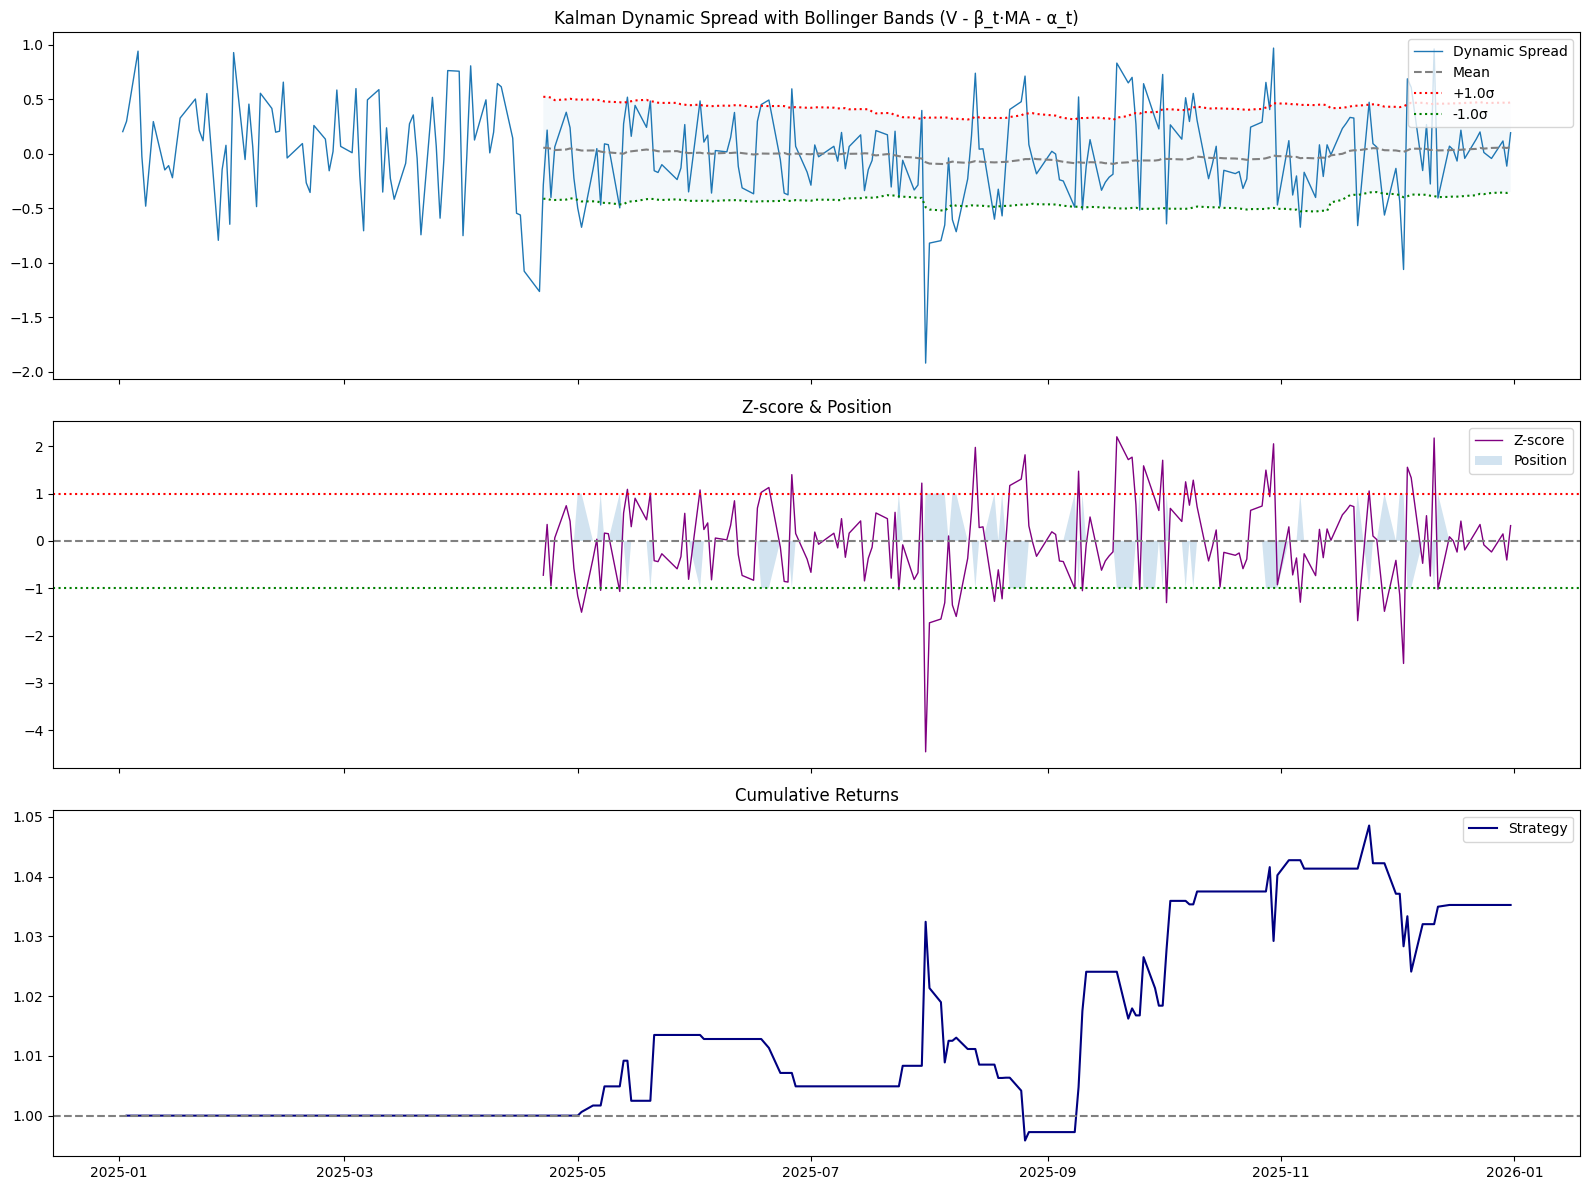

In [39]:
# holdout
test_close = df_test['Adj Close'][[t1, t2]].dropna().copy()
x_test = test_close[t1]
y_test = test_close[t2]

# fit Kalman on full training period, apply online to holdout
state_train, state_covs_train, _ = calc_kalman_slope_intercept(
    x_train, y_train, delta=1e-5, obs_noise=1.0
)

last_state_mean = state_train[['beta', 'intercept']].iloc[-1].values
last_state_cov = state_covs_train[-1]

state_test = kalman_filter_holdout_online(
    x_test, y_test,
    last_state_mean=last_state_mean,
    last_state_cov=last_state_cov,
    delta=1e-5,
    obs_noise=1.0
)

perf_test, total_return, annual_ret, sharpe, max_dd = kalman_bollinger_holdout_strategy(
    x_prices=x_test,
    y_prices=y_test,
    state_df=state_test,
    name_x='MA',
    name_y='V',
    window=75,
    entry=1.0,
    exit=0.8,
    plot=True
)